In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import problem
import os
pd.set_option('display.max_columns', None)

In [19]:
X_df, y = problem.get_train_data(load_waveform=False)

os.environ["RAMP_TEST_MODE"] = "1"

X_v, y = problem.get_train_data(start=0, stop=100)
X_m, y_m = problem.get_train_data(start=-101, stop=-1)
X_df = pd.concat([X_v, X_m], axis=0).reset_index()
y = np.concatenate([y, y_m])


In [4]:
X_df.head()

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN


In [14]:
X_df.describe()

,n_seg,age,height,weight,bmi,id
count,4200.000000,4200.000000,2000.000000,2000.000000,2000.000000,4200.000000
mean,1238.773333,56.499048,164.225000,61.525000,22.775000,127.799524
std,904.476281,16.784600,3.845682,9.509842,3.056394,204.871719
min,264.000000,32.000000,159.200000,50.600000,19.300000,1.000000
25%,396.000000,48.000000,161.300000,54.875000,20.050000,2.000000
50%,688.000000,54.000000,164.350000,59.700000,22.600000,4.000000
75%,1984.000000,76.000000,167.275000,66.350000,25.325000,186.000000
max,3756.000000,84.000000,169.000000,76.100000,26.600000,535.000000


In [9]:
X_df.isna().sum()

n_seg           0
subject         0
age             0
gender          0
domain          0
height      79499
weight      79499
bmi         79499
id              0
chunk      300000
dtype: int64

In [40]:
features

{'heart_rate': np.float64(0.5154639175257731),
 'sdnn': np.float64(1.6852299546352716),
 'rmssd': np.float64(2.160246899469287)}

In [45]:
from scipy.signal import find_peaks

k = 10
ecg = np.array(X_df['ecg'])  # Convert to numpy array
peaks, peak_prop = find_peaks(ecg[k], distance = 50)  # Ajustez distance selon la fréquence d'échantillonnage
rr_intervals = np.diff(peaks)  # Intervalles RR
features = {
    "heart_rate": 60 / np.mean(rr_intervals),  # Fréquence cardiaque moyenne
    "sdnn": np.std(rr_intervals),
    "rmssd": np.sqrt(np.mean(np.diff(rr_intervals)**2))
}

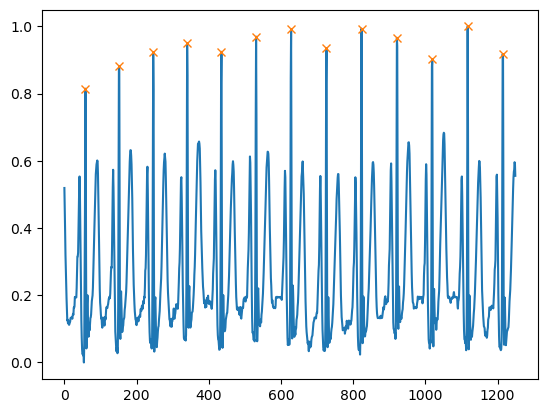

In [46]:
# Plot des peaks et du signal ECG
plt.plot(ecg[k])
plt.plot(peaks, ecg[k][peaks], "x")
plt.show()


In [33]:
rr_intervals

array([117, 117, 119, 116, 117, 116, 117, 117, 116])